<a href="https://colab.research.google.com/github/romainstead/one_layer_nn/blob/main/nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from tqdm.notebook import tqdm

# Задание 1

In [2]:
class Perceptron:
    def __init__(self, lr, epochs):
        self.lr = lr
        self.weights = None
        self.epochs = epochs
        self.bias = 0

    def activation(self, z):
        return np.heaviside(z, 0) # функция хэвисайда

    def fit(self, X, y):
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)

        for epoch in range(self.epochs):
            for i in range(len(X)):
                z = np.dot(X[i], self.weights) + self.bias # линейная комбинация весов и входных данных
                y_pred = self.activation(z) # определение выходного сигнала нейрона
                error = y[i] - y_pred # вычисление ошибки
                self.weights += self.lr * error * X[i] # подгоняем веса под ошибку
                self.bias += self.lr * error # подгоняем смещение на ошибку
        return self.weights, self.bias

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.activation(z)

In [3]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])
nn = Perceptron(0.01, 5)
nn.fit(X, y)
print(nn.predict(X))

[0. 0. 0. 1.]


# Задание 2

# Загрузка датасета

In [19]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train
y_train = y_train
x_test = x_test
y_test = y_test
print(y_test)

[7 2 1 ... 4 5 6]


# Построение нейросети и обучение

In [56]:
rng = np.random.default_rng(seed=42)
np.set_printoptions(suppress=True, precision=6)

mse_errors = []

class Network:
    def __init__(self, n_out, epochs, lr):
        self.n_out = n_out
        self.lr = lr
        self.epochs = epochs
        self.bias = np.zeros([10,]) # 10 выходных нейронов - вектор из 10 биасов для каждого нейрона
        self.weights = None

    def activation(self, z):
        return np.exp(z) / (np.exp(z) + 1)

    def fit(self, X, y):
        y_onehot = np.eye(self.n_out)[y] # превращение числа в вектор, где единица стоит на индексе, равным самому числу
        n_features = X.shape[1] * X.shape[2] # входной слой - 28*28
        self.weights = np.zeros([n_features, self.n_out]) # инициализация весов [784, 10]
        for epoch in tqdm(range(self.epochs)):
            for i in range(len(X)):
                z = np.dot(X[i].flatten(), self.weights) + self.bias # скалярное произведение весов с входным сигналом + биас
                y_pred = self.activation(z) # пропуск полученных значений через функцию активации
                error = y_onehot[i] - y_pred # вычисление ошибки
                deriv = y_pred * (1 - y_pred)
                delta = error * deriv # градиентный спуск
                self.weights += self.lr * np.outer(X[i].flatten(), delta)
                self.bias += self.lr * delta
            loss = np.mean((y_onehot[i] - y_pred) ** 2)
            print(f"Epoch {epoch + 1}, train loss={loss}")
            mse_errors.append(loss)
        return self.weights, self.bias

    def predict(self, X):
        z = np.dot(X.flatten(), self.weights) + self.bias
        return self.activation(z)

net = Network(10, 30, 0.001)
net.fit(x_train, y_train)

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1, train loss=0.037671253627629846
Epoch 2, train loss=0.030307049712325628
Epoch 3, train loss=0.028804599891931217
Epoch 4, train loss=0.02827056101717696
Epoch 5, train loss=0.02791749923113578
Epoch 6, train loss=0.02756473976092525
Epoch 7, train loss=0.02716892842731512
Epoch 8, train loss=0.026725118267146537
Epoch 9, train loss=0.02623981666170109
Epoch 10, train loss=0.025722456143573668
Epoch 11, train loss=0.02518248682157298
Epoch 12, train loss=0.02462839533706972
Epoch 13, train loss=0.02406743590665832
Epoch 14, train loss=0.023505634123916572
Epoch 15, train loss=0.022947892664726736
Epoch 16, train loss=0.022398128997563937
Epoch 17, train loss=0.021859415799354562
Epoch 18, train loss=0.021334112007448478
Epoch 19, train loss=0.020823980051023042
Epoch 20, train loss=0.020330288248820633
Epoch 21, train loss=0.019853898914200818
Epoch 22, train loss=0.019395343373714208
Epoch 23, train loss=0.018954885340662135
Epoch 24, train loss=0.01853257410973148
Epoch 25, 

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([-1.103881, -0.357462, -1.172724, -1.492753, -0.771454, -0.295232,
        -1.031819, -0.385087, -3.016077, -1.753016]))

# График loss = f(epoch)

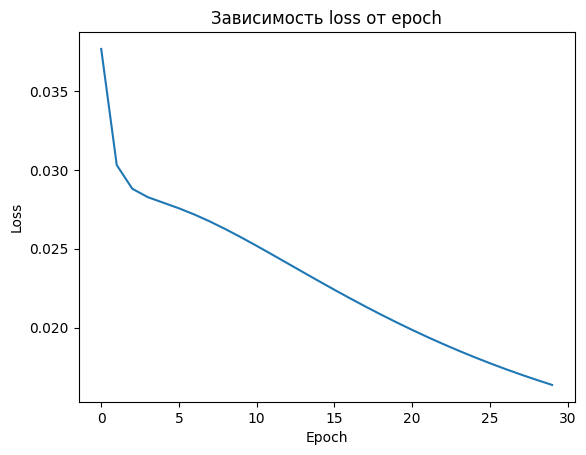

In [57]:
plt.plot(mse_errors)
plt.title('Зависимость loss от epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Валидация

In [58]:
print(np.argmax(net.predict(x_test[0])))
print(y_test[0])

7
7


In [59]:
true_counter = 0
for i in range(len(x_test)):
    if np.argmax(net.predict(x_test[i])) == y_test[i]:
        true_counter += 1
print(f"Точность модели: {true_counter / len(x_test)}")

Точность модели: 0.9136


# Матрица ошибок

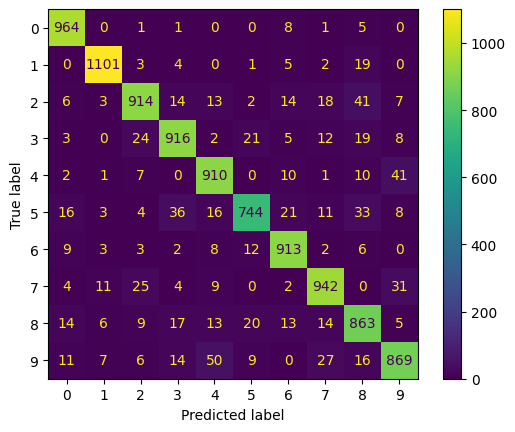

In [60]:
y_true = y_test
y_pred = []
for i in range(len(x_test)):
    y_pred.append(np.argmax(net.predict(x_test[i])))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()